In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import cv2

cv2.__version__
# Загрузка и предобработка данных MNIST
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Нормализация данных

# Добавление канала (для сверточной сети требуется 3D-формат входных данных)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Создание модели сверточной нейронной сети
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Компиляция модели
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Обучение модели
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# Оценка точности модели на тестовом наборе
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc:.2f}')

# Предсказание на тестовых данных
predictions = model.predict(x_test)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8894 - loss: 0.3604 - val_accuracy: 0.9837 - val_loss: 0.0527
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9831 - loss: 0.0524 - val_accuracy: 0.9888 - val_loss: 0.0407
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9887 - loss: 0.0351 - val_accuracy: 0.9895 - val_loss: 0.0380
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9920 - loss: 0.0249 - val_accuracy: 0.9887 - val_loss: 0.0418
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9935 - loss: 0.0195 - val_accuracy: 0.9895 - val_loss: 0.0348
313/313 - 1s - 3ms/step - accuracy: 0.9910 - loss: 0.0285

Test accuracy: 0.99
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


1: pred - 9, true - 4
2: pred - 6, true - 4
3: pred - 8, true - 9
4: pred - 7, true - 2
5: pred - 0, true - 6
6: pred - 9, true - 4
7: pred - 5, true - 3
8: pred - 9, true - 7
9: pred - 8, true - 1
10: pred - 4, true - 6
11: pred - 7, true - 2
12: pred - 7, true - 1
13: pred - 4, true - 0
14: pred - 5, true - 7
15: pred - 7, true - 9
16: pred - 9, true - 8
17: pred - 0, true - 6
18: pred - 1, true - 7
19: pred - 6, true - 4
20: pred - 8, true - 6
21: pred - 2, true - 7
22: pred - 5, true - 9
23: pred - 7, true - 5
24: pred - 3, true - 8
25: pred - 3, true - 2


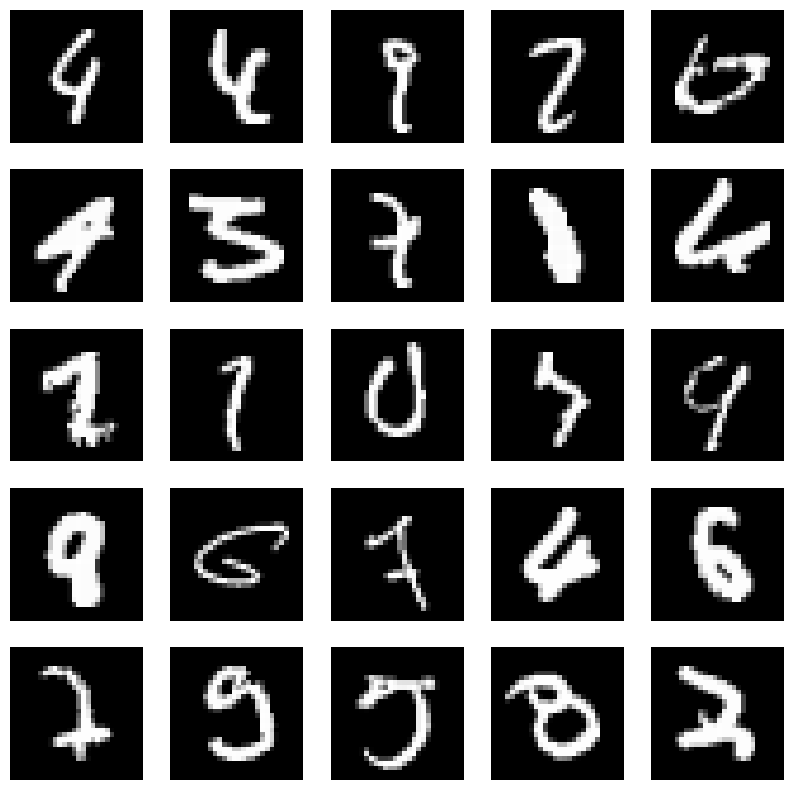

In [15]:
# Поиск и отображение неверно предсказанных изображений
incorrect_indices = np.where(np.argmax(predictions, axis=1) != y_test)[0]
plt.figure(figsize=(10, 10))

for i, idx in enumerate(incorrect_indices[:25]):  # Покажем 25 неверных предсказаний
    img = x_test[idx].reshape(28, 28)
    img = (img * 255).astype(np.uint8)  # Преобразуем к формату uint8 для OpenCV
    
    # Предсказанный и правильный классы
    predicted_label = np.argmax(predictions[idx])
    true_label = y_test[idx]
    
    # Используем OpenCV для отображения изображения с предсказанием
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    #up_width = img_rgb.size * 10
    #up_height = img_rgb.size * 10
    #up_points = (up_width, up_height)
    #img_rgb = cv2.resize(img_rgb, up_points, interpolation= cv2.INTER_LINEAR)
    
#    cv2.putText(img_rgb, f"{predicted_label}, {true_label}", (5, 20), 
#               cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 0, 0), 1, cv2.LINE_AA)
    print (f"{i+1}: pred - {predicted_label}, true - {true_label}")
    plt.subplot(5, 5, i + 1)
    plt.imshow(img_rgb)
    plt.axis('off')

plt.show()